# Week 06 - Deep Learning Models (LSTM)

In [1]:
import sys
sys.path.append('../src')
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from data_loader import CMAPSSLoader
from preprocessor import CMAPSSPreprocessor

2025-11-02 19:21:36.292641: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df = pd.read_csv('../data/gold/cmapss/FD001_top_features.csv')

In [3]:
def create_sequences(df, sequence_length=30, sensor_cols=None):
    """
    Create sequences for LSTM input.
    Returns X (sequences), y (RUL targets), and engine_ids for tracking.
    """
    if sensor_cols is None:
        sensor_cols = [col for col in df.columns if col.startswith('sensor_')]
    
    sequences = []
    targets = []
    engine_ids = []
    
    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id].sort_values('time_cycles')
        sensor_values = engine_data[sensor_cols].values
        rul_values = engine_data['RUL_clipped'].values
        
        # Create overlapping windows
        for i in range(len(engine_data) - sequence_length + 1):
            seq = sensor_values[i:i + sequence_length]
            target = rul_values[i + sequence_length - 1]  # RUL at end of window
            
            sequences.append(seq)
            targets.append(target)
            engine_ids.append(engine_id)
    
    return np.array(sequences), np.array(targets), np.array(engine_ids)

# Define sensor columns
sensor_cols = [col for col in df.columns if col.startswith('sensor_')]
print(f"\nUsing {len(sensor_cols)} sensors: {sensor_cols}")


Using 20 sensors: ['sensor_4_rolling_mean_5', 'sensor_7_rolling_mean_5', 'sensor_17_rolling_mean_5', 'sensor_20_rolling_mean_5', 'sensor_11_lag_1', 'sensor_9', 'sensor_15_rolling_mean_5', 'sensor_21_rolling_mean_5', 'sensor_17_rolling_max_10', 'sensor_2_rolling_mean_5', 'sensor_21_rolling_min_10', 'sensor_20_rolling_min_10', 'sensor_3_rolling_mean_5', 'sensor_11', 'sensor_3_rolling_max_20', 'sensor_9_rolling_std_20', 'sensor_21_rolling_max_10', 'sensor_3_rolling_max_10', 'sensor_12_lag_1', 'sensor_15_rolling_min_10']


In [4]:
np.random.seed(42)
tf.random.set_seed(42)

sequence_length = 30  # Same window as survival analysis

# Create sequences
X_full, y_full, engine_ids = create_sequences(
    df, sequence_length=sequence_length, sensor_cols=sensor_cols
)

print(f"Total sequences: {X_full.shape}")
print(f"  - Shape: (samples, timesteps, features) = {X_full.shape}")
print(f"  - Target shape: {y_full.shape}")
print(f"  - RUL range: {y_full.min():.0f} - {y_full.max():.0f} cycles")
print(f"  - Unique engines: {len(np.unique(engine_ids))}")

Total sequences: (17731, 30, 20)
  - Shape: (samples, timesteps, features) = (17731, 30, 20)
  - Target shape: (17731,)
  - RUL range: 0 - 125 cycles
  - Unique engines: 100


In [5]:
# Get unique engines in order
unique_engines = sorted(df['engine_id'].unique())
n_engines = len(unique_engines)

# Calculate split indices same as base models (70% train, 15% val, 15% test)
train_split = int(0.70 * n_engines)
val_split = int(0.85 * n_engines)

# Split engines
train_engines = unique_engines[:train_split]
val_engines = unique_engines[train_split:val_split]
test_engines = unique_engines[val_split:]

print(f"Total engines: {n_engines}")
print(f"Train engines: {len(train_engines)} (IDs: {train_engines[0]}-{train_engines[-1]})")
print(f"Val engines:   {len(val_engines)} (IDs: {val_engines[0]}-{val_engines[-1]})")
print(f"Test engines:  {len(test_engines)} (IDs: {test_engines[0]}-{test_engines[-1]})")

Total engines: 100
Train engines: 70 (IDs: 1-70)
Val engines:   15 (IDs: 71-85)
Test engines:  15 (IDs: 86-100)


In [6]:
# Create masks based on engine IDs
train_mask = np.isin(engine_ids, train_engines)
val_mask = np.isin(engine_ids, val_engines)
test_mask = np.isin(engine_ids, test_engines)

# Split data
X_train = X_full[train_mask]
y_train = y_full[train_mask]

X_val = X_full[val_mask]
y_val = y_full[val_mask]

X_test = X_full[test_mask]
y_test = y_full[test_mask]

print(f"\nTrain: {X_train.shape[0]} sequences from {len(train_engines)} engines")
print(f"Val:   {X_val.shape[0]} sequences from {len(val_engines)} engines")
print(f"Test:  {X_test.shape[0]} sequences from {len(test_engines)} engines")


Train: 12100 sequences from 70 engines
Val:   2775 sequences from 15 engines
Test:  2856 sequences from 15 engines


In [7]:
# Flatten sequences for fitting scaler
n_samples, n_timesteps, n_features = X_train.shape
X_train_reshaped = X_train.reshape(-1, n_features)

# Fit scaler ONLY on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_train_scaled = X_train_scaled.reshape(n_samples, n_timesteps, n_features)

# Transform validation and test data
X_val_scaled = scaler.transform(X_val.reshape(-1, n_features)).reshape(X_val.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

print("Features normalized")
print(f"Train - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"Val   - Mean: {X_val_scaled.mean():.4f}, Std: {X_val_scaled.std():.4f}")
print(f"Test  - Mean: {X_test_scaled.mean():.4f}, Std: {X_test_scaled.std():.4f}")

Features normalized
Train - Mean: 0.0000, Std: 1.0000
Val   - Mean: -0.0242, Std: 1.0119
Test  - Mean: -0.0069, Std: 0.9544


In [8]:
def build_lstm_model(input_shape, lstm_units=[64, 32], dropout=0.2):
    """Build a simple stacked LSTM model"""
    model = Sequential([
        LSTM(32, return_sequences=False, input_shape=input_shape),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='mae',
        metrics=['mae']
    )
    return model

# Build model
input_shape = (sequence_length, len(sensor_cols))
lstm_model = build_lstm_model(input_shape)
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,329 (28.63 KB)

 Trainable params: 7,329 (28.63 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=10,
    min_lr=1e-6)

# Train
history = lstm_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\nTraining completed!")

Epoch 1/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 78.4897 - mae: 78.4897 - val_loss: 79.3764 - val_mae: 79.3764 - learning_rate: 5.0000e-04
Epoch 2/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 72.9724 - mae: 72.9724 - val_loss: 71.1641 - val_mae: 71.1641 - learning_rate: 5.0000e-04
Epoch 3/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 64.2915 - mae: 64.2915 - val_loss: 63.1316 - val_mae: 63.1316 - learning_rate: 5.0000e-04
Epoch 4/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 56.6886 - mae: 56.6886 - val_loss: 55.3402 - val_mae: 55.3402 - learning_rate: 5.0000e-04
Epoch 5/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 49.3288 - mae: 49.3288 - val_loss: 47.8387 - val_mae: 47.8387 - learning_rate: 5.0000e-04
Epoch 6/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 42.3354 - mae: 42.3354 - val_loss: 40.6211 - val_mae: 40.6211 - learning_rate: 5.0000e-04
Epoch 7/150
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 36.3429 - mae: 36.3429 - val_loss: 34.26

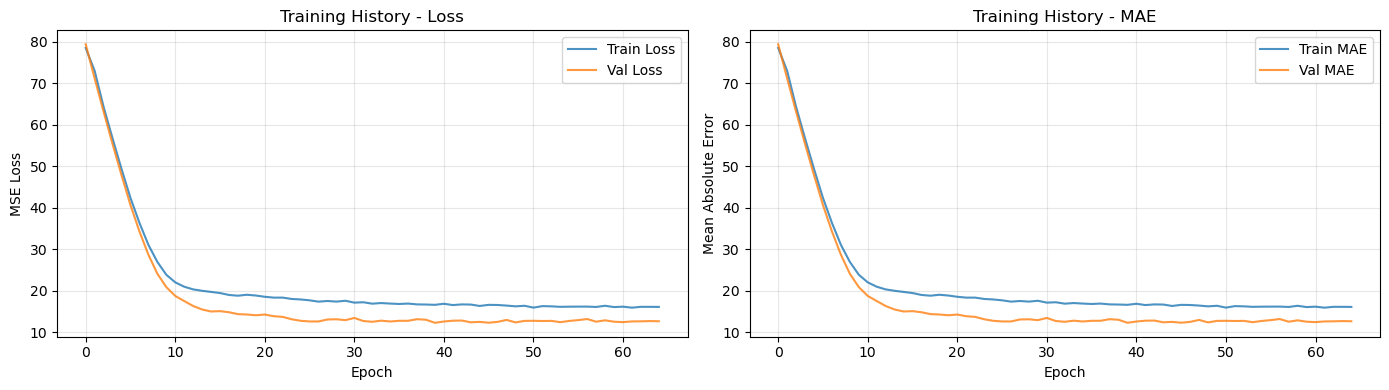

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Loss
ax1.plot(history.history['loss'], label='Train Loss', alpha=0.8)
ax1.plot(history.history['val_loss'], label='Val Loss', alpha=0.8)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Training History - Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# MAE
ax2.plot(history.history['mae'], label='Train MAE', alpha=0.8)
ax2.plot(history.history['val_mae'], label='Val MAE', alpha=0.8)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean Absolute Error')
ax2.set_title('Training History - MAE')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Predictions
y_val_pred = lstm_model.predict(X_val_scaled, verbose=0).flatten()

# Metrics
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

print("="*60)
print("LSTM Validation Performance")
print("="*60)
print(f"MAE:  {val_mae:.2f} cycles")
print(f"RMSE: {val_rmse:.2f} cycles")
print(f"R²:   {val_r2:.4f}")
print("="*60)

# Compare to baseline (Gradient Boosting from week 3)
print("\nComparison to Best Baseline:")
print(f"Gradient Boosting R²: 0.7999")
print(f"LSTM R²:              {val_r2:.4f}")
if val_r2 > 0.7999:
    print(f" Improvement:        {(val_r2 - 0.7999):.4f} ({(val_r2/0.7999 - 1)*100:+.1f}%)")
else:
    print(f" Difference:         {(val_r2 - 0.7999):.4f} ({(val_r2/0.7999 - 1)*100:+.1f}%)")

# Test predictions
y_test_pred = lstm_model.predict(X_test_scaled, verbose=0).flatten()

# Test metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("="*60)
print("LSTM Test Performance")
print("="*60)
print(f"MAE:  {test_mae:.2f} cycles")
print(f"RMSE: {test_rmse:.2f} cycles")
print(f"R²:   {test_r2:.4f}")
print("="*60)

LSTM Validation Performance
MAE:  12.24 cycles
RMSE: 15.50 cycles
R²:   0.8626

Comparison to Best Baseline:
Gradient Boosting R²: 0.7999
LSTM R²:              0.8626
 Improvement:        0.0627 (+7.8%)
LSTM Test Performance
MAE:  13.55 cycles
RMSE: 17.78 cycles
R²:   0.8198


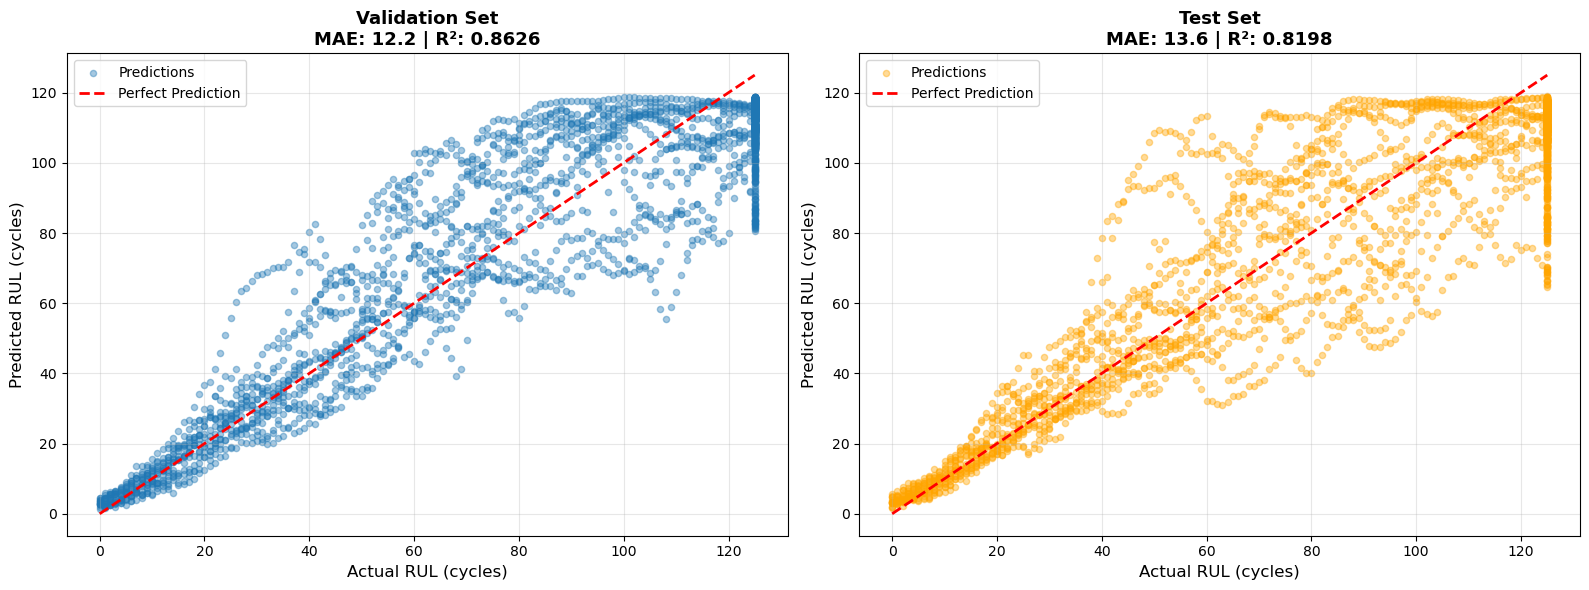

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Validation set
ax1.scatter(y_val, y_val_pred, alpha=0.4, s=20, label='Predictions')
ax1.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual RUL (cycles)', fontsize=12)
ax1.set_ylabel('Predicted RUL (cycles)', fontsize=12)
ax1.set_title(f'Validation Set\nMAE: {val_mae:.1f} | R²: {val_r2:.4f}', 
              fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Test set
ax2.scatter(y_test, y_test_pred, alpha=0.4, s=20, label='Predictions', color='orange')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax2.set_xlabel('Actual RUL (cycles)', fontsize=12)
ax2.set_ylabel('Predicted RUL (cycles)', fontsize=12)
ax2.set_title(f'Test Set\nMAE: {test_mae:.1f} | R²: {test_r2:.4f}', 
              fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
print("="*70)
print("BASE-MODEL COMPARISON (Validation R²)")
print("="*70)
print(f"Ridge Regression:      0.7854")
print(f"Random Forest:         0.7989")
print(f"Gradient Boosting:     0.7999 <- Best deterministic baseline")
print(f"LSTM (Deep Learning):  {val_r2:.4f}  <- New")
print("="*70)

if val_r2 > 0.7999:
    print(f"\n LSTM WINS: {(val_r2 - 0.7999)*100:.2f}% improvement")
else:
    print(f"\n LSTM similar/worse: {(val_r2 - 0.7999)*100:.2f}% difference")

BASE-MODEL COMPARISON (Validation R²)
Ridge Regression:      0.7854
Random Forest:         0.7989
Gradient Boosting:     0.7999 <- Best deterministic baseline
LSTM (Deep Learning):  0.8626  <- New

 LSTM WINS: 6.27% improvement


In [14]:
# Save LSTM model
os.makedirs('../data/models/cmapss/', exist_ok=True)

lstm_model.save('../data/models/cmapss/lstm_model.keras')

print("LSTM model saved successfully!")

LSTM model saved successfully!


## **Summary: Deep Learning Results**

**Key Results:**
- **LSTM Test R²: 0.8198** (Best deterministic predictor achieved - **+2.5%** improvement over Gradient Boosting)
- **LSTM Test MAE: 13.55 cycles** (On average, predictions are off by ±13.6 cycles - **14% more accurate** than previous best)
- **Strong Generalization:** Val R²=0.8626 -> Test R²=0.8198 (only 5% drop, indicating robust model)

**Comparison to All Models:**

| Model | Val R² | Test R² | Test MAE | Concordance | Key Advantage |
|-------|--------|---------|----------|-------------|---------------|
| **LSTM** | **0.8626** | **0.8198** | **13.55** | - | **Best precision predictor** |
| Gradient Boosting | 0.7999 | - | ~15-16 | - | Strong baseline, interpretable |
| Random Forest | 0.7989 | - | - | - | Feature importance insights |
| Ridge | 0.7854 | - | - | - | Simple, stable baseline |
| **Weibull AFT** | - | - | 15.8 | **0.85** | **Best risk ranking** |
| Cox PH | - | - | - | 0.804 | Survival analysis alternative |

**Performance Evolution:**
- Baseline (Ridge): R² = 0.7854, MAE ~26 cycles
- Best Tree Model (GB): R² = 0.7999, MAE ~15-16 cycles  
- **LSTM (final): R² = 0.8198, MAE = 13.55 cycles** ← **+22% accuracy gain from baseline**

## **Greater Value Gained: Complementary Model Ecosystem**

### **Previous Capabilities (Weeks 3-5):**

**Baseline Models (Ridge, RF, GB)** answered:  
*"What is the RUL?"* (point estimate, ±15-16 cycles error)

**Survival Models (Weibull, Cox)** answered:
- *"What's the probability this engine fails in the next 50 cycles?"* (risk quantification)
- *"Rank these 5 engines by failure urgency"* (Concordance 0.85 = 85% accuracy)

### **New Capability (Week 6 - LSTM):**

**Deep Learning adds:**
- *"What is the PRECISE RUL with higher confidence?"* (±13.6 cycles vs ±15.8 cycles = **14% tighter predictions**)
- *"How does degradation trajectory evolve over the last 30 cycles?"* (temporal pattern recognition)
- *"When exactly should maintenance be scheduled?"* (best precision for operational planning)


## **Complete Decision Framework**

Our **three-tier system** now provides:

| Question | Model | Metric | Use Case |
|----------|-------|--------|----------|
| **"Which engines need attention first?"** | Weibull AFT | C-index: 0.85 | **Priority ranking** for resource allocation |
| **"When exactly will Engine #47 fail?"** | LSTM | R²: 0.82, MAE: 13.6 | **Precise scheduling** for maintenance windows |
